In [2]:
cd /lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO/notebooks/

/lustre/fsn1/projects/rech/omr/romr004/code/ZB_DINO/notebooks


In [3]:
import importlib
import sys; from __init__ import PRP

sys.path.append(f'{PRP}/notebooks/dinostics/')
import experiment
importlib.reload(experiment)  # optional if editing without restart
from experiment import NemoExperiment

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mplcolors
import cmocean as cm

# Load experiments

In [8]:
base_path = '/lustre/fsstor/projects/rech/omr/uym68qx/nemo_output/DINO/Dinoffusion/'
blandine_base = '/lustre/fsn1/projects/rech/omr/romr004/DINO/Diffusion_runs/'

#'/lustre/fsn1/projects/rech/omr/uym68qx/DINO/'

In [10]:
#'/lustre/fswork/projects/rech/omr/uym68qx/data/'

expR4 = NemoExperiment(
    path= base_path,
    experiment_name='1_4degree',
    restarts=['restart25', 'restart26', 'restart27', 'restart28'],
    files = ['T_3D']
)

expR4.data['inst_T_3D'] = expR4.data['T_3D'] 
expR4.data['T_3D'] = expR4.data['inst_T_3D'].groupby('t.year').mean(dim='t')
expR4.data['T_3D'] = expR4.data['T_3D'].rename({'year': 't'})
expR4.data['T_3D'] = expR4.data['T_3D'].rename({'toce_inst': 'toce', 'soce_inst': 'soce'})

expR4.description = 'Simulation 1/4 degree'


# expC1 = NemoExperiment(
#     path= blandine_base,
#     experiment_name='Blandine',
#     restarts=['restart25_C1'],
#     files = ['inst_T_3D', 'T_3D']
# )

# expC1.description = 'Diffusion Constraint 1'

# expC2 = NemoExperiment(
#     path= blandine_base,
#     experiment_name='Blandine',
#     restarts=['restart25_C2'],
#     files = ['inst_T_3D', 'T_3D']
# )

# expC2.description = 'Diffusion Constraint 2'

expC2 = NemoExperiment(
    path= blandine_base,
    experiment_name='Constraint_2',
    restarts=['restart0'],
    files = ['inst_T_3D', 'T_3D']
)

expC2.description = 'Diffusion Constraint 2'

exps = [expR4, expC2]

# Figures using yearly average

In [11]:
for exp in exps :
    s = exp.diagnostics.get_rho(T=exp.data['T_3D'].toce,
                                  S=exp.data['T_3D'].soce,
                                  z=2000.).where(exp.mask.tmask==1.0).mean('x_c')
    
    s = s.assign_coords(lat=exp.data['T_3D'].gphit.isel(x_c=10),
                        depth_plot=('z_c',exp.mask.gdepw_1d.shift(z_f=-1, fill_value=4250.).values)) - 1000
    
    exp.data['T_3D']['Sigma'] = s

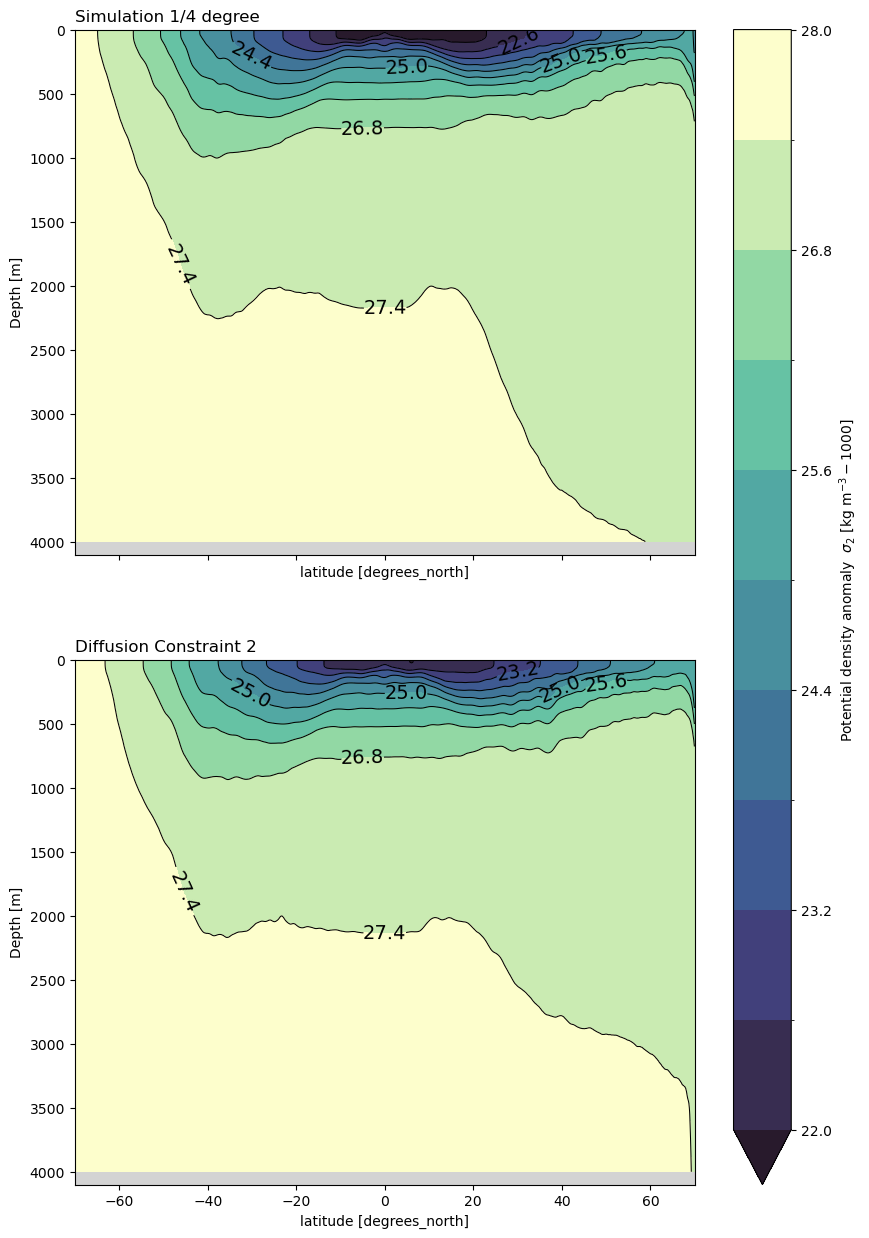

In [12]:
fig_dense, axs = plt.subplots(len(exps),1, figsize=(10,15), sharex=True, sharey=True)
levels = np.linspace(22.,28.,11)

for i, exp in enumerate(exps) :
    sigma_mean = exp.data['T_3D'].Sigma.isel(t=slice(-2, -1)).mean('t').compute()
    
    a = sigma_mean.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat',
                                 y='depth_plot', ax=axs[i], add_colorbar=False, yincrease=False)
    
    contour_1 = sigma_mean.plot.contour(levels=levels, colors='k', linewidths=0.75,
                                        x='lat', y='depth_plot', ax=axs[i], yincrease=False)
    
    plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=14,
               manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (40,250)])
    axs[i].set_ylabel(r'Depth [m]')
    axs[i].set_title(exp.description, loc='left')
    axs[i].set_facecolor("lightgray")
    axs[i].set_ylim(4100,0)

    #axs[i].set_xlabel('')
    #axs[1].set_xlabel(r'Latitude [$^{\circ} \, \text{N}$]')

cbar1 = fig_dense.colorbar(a, ax=axs, label=r'Potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')


# Figures using daily avgs

In [13]:
for exp in exps :
    s = exp.diagnostics.get_rho(T=exp.data['inst_T_3D'].toce_inst,
                                  S=exp.data['inst_T_3D'].soce_inst,
                                  z=2000.).where(exp.mask.tmask==1.0).mean('x_c')
    
    s = s.assign_coords(lat=exp.data['inst_T_3D'].gphit.isel(x_c=10),
                        depth_plot=('z_c',exp.mask.gdepw_1d.shift(z_f=-1, fill_value=4250.).values)) - 1000
    
    exp.data['inst_T_3D']['Sigma'] = s

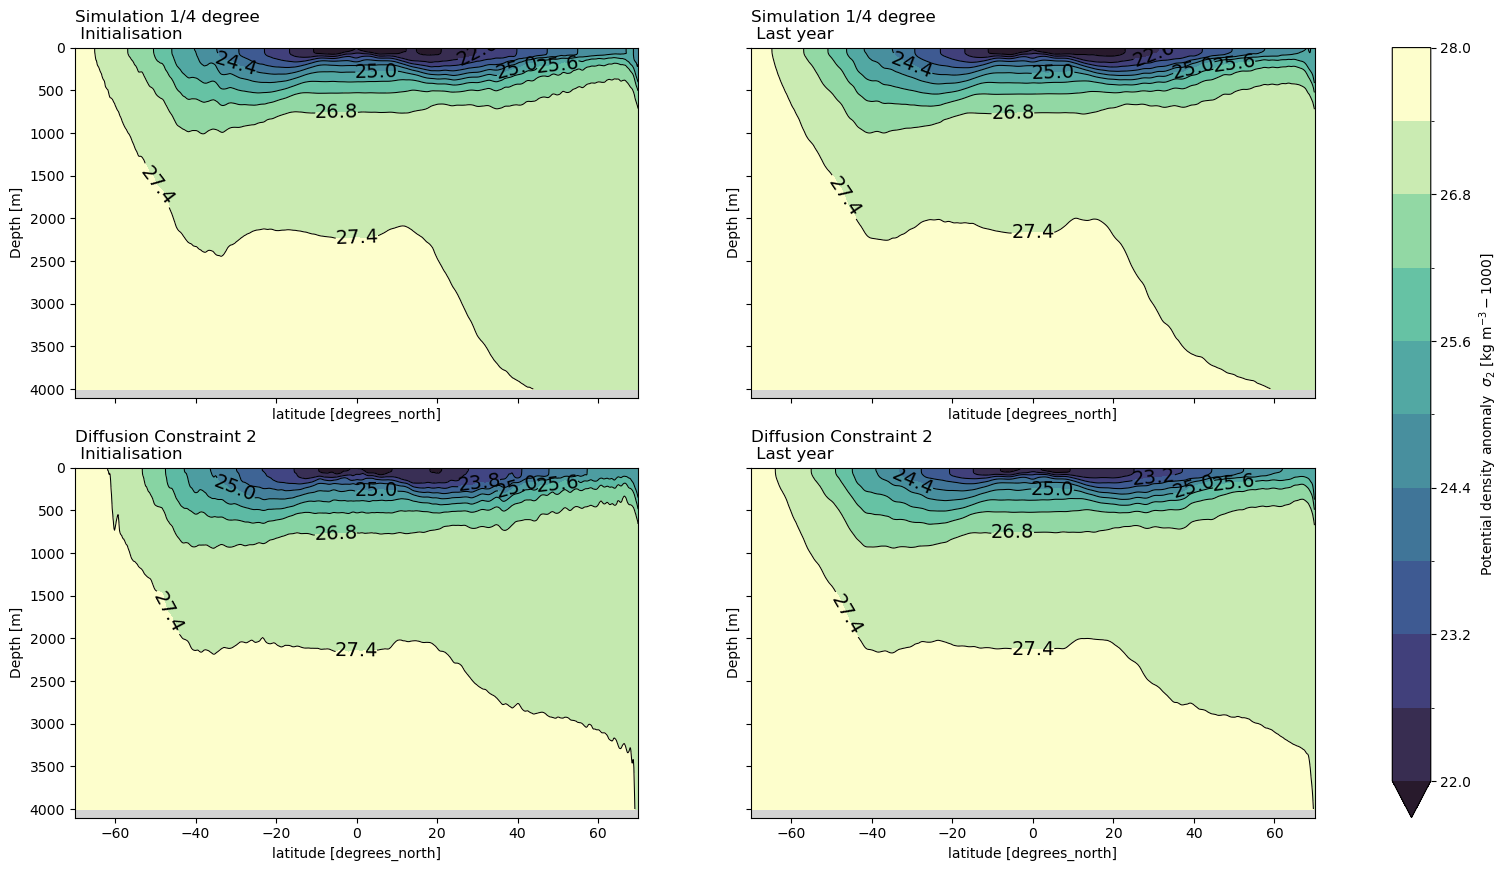

In [14]:
fig_dense, axs = plt.subplots(len(exps), 2, figsize=(20, 10), sharex=True, sharey=True)
levels = np.linspace(22.,28,11)

for i, exp in enumerate(exps) :
    for j, s in enumerate([{'name' : 'Initialisation', 'slice' : slice(0,1)},
                           {'name' : 'Last year', 'slice' : slice(-36, -1)}]) : 
        
        sigma_mean = exp.data['inst_T_3D'].Sigma.isel(t=s['slice']).mean('t').compute()
            
        a = sigma_mean.plot.contourf(levels=levels, cmap=cm.cm.deep_r, x='lat',
                                     y='depth_plot', ax=axs[i, j], add_colorbar=False, yincrease=False)
        
        contour_1 = sigma_mean.plot.contour(levels=levels, colors='k', linewidths=0.75,
                                            x='lat', y='depth_plot', ax=axs[i, j], yincrease=False)
        
        plt.clabel(contour_1, fmt="%.1f", inline=True, fontsize=14,
                   manual=[(-55,2000),(0,2000),(-5,700),(50,200), (5,300),(-30,200), (30,50), (40,250)])

        axs[i, j].set_ylabel(r'Depth [m]')
        axs[i, j].set_title(f'{exp.description} \n {s["name"]}', loc='left')
        axs[i, j].set_facecolor("lightgray")
        axs[i, j].set_ylim(4100,0)
        
cbar1 = fig_dense.colorbar(a, ax=axs, label=r'Potential density anomaly  $\sigma_{2}$ [$\text{kg}$ $\text{m}^{-3} - 1000$]')
